# Task 4 — Neural Machine Translation with Attention

**Project 2.2 · Vasilis & Riccardo**

This notebook adds an **attention mechanism** to the Task 3 encoder–decoder and measures
what it buys us.

**Why attention.** In Task 3 the encoder compresses the whole source sentence into a
*single* fixed vector, and the decoder sees only that vector. Everything the model knows
about a 20-word sentence must fit in 256 numbers. This is the *information bottleneck*,
and it is the main reason the Task 3 models produce generic output and degrade on long
sentences.

Attention removes the bottleneck: at **every** decoding step the decoder looks back at
**all** encoder states and computes a weighted average of them, learning which source
words matter for the target word it is generating right now.

**Experimental design.** To make the with/without comparison fair, this notebook trains
*both* models itself, using identical data splits, vocabularies, hyperparameters and
random seeds. The only difference is the attention mechanism.

In [2]:
!nvidia-smi


Mon Jul 20 12:35:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# --- Colab setup (skipped when running locally) ---
import os, sys, subprocess
from pathlib import Path

REPO = "https://github.com/riccardotella/English-Italian-Machine-Translation-.git"

if "google.colab" in sys.modules:
    if not Path("English-Italian-Machine-Translation-").exists():
        subprocess.run(["git", "clone", REPO], check=True)
    os.chdir("English-Italian-Machine-Translation-")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "nltk"], check=True)

print("cwd:", os.getcwd())

cwd: /content/English-Italian-Machine-Translation-


In [4]:
# --- Imports, seeds, device ---
import random, json, math, time
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Task 3 ran on CPU; attention is heavier, so use the GPU when Colab gives us one.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Resolve project root whether we launch from notebooks/ or the repo root.
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR     = PROJECT_ROOT / "models" / "task4"
RESULTS_DIR   = PROJECT_ROOT / "results" / "task4_outputs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EN_PATH = PROCESSED_DIR / "task2_clean.en"
IT_PATH = PROCESSED_DIR / "task2_clean.it"
if not (EN_PATH.exists() and IT_PATH.exists()):
    raise FileNotFoundError(
        "Task 2 outputs missing. They are committed to the repo under data/processed/."
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {DEVICE}")

Project root : /content/English-Italian-Machine-Translation-
Device       : cuda


In [5]:
# --- Repair the Task 2 outputs if they still carry CSV quoting ---
# Task 2 saved the cleaned text with pandas .to_csv(), which wraps any field
# containing a comma in double quotes and doubles any real quote inside it. 64% of
# lines were affected, so the models were trained on strings like
#     "madam president, on a point of order."
# The sibling task2_clean_parallel.csv is a correct CSV, so the clean text is
# recoverable without re-running Task 2. This cell is idempotent: it does nothing
# if the files are already clean.
CSV_PATH = PROCESSED_DIR / "task2_clean_parallel.csv"

def _looks_quoted(path, sample=2000):
    with open(path, encoding="utf-8") as f:
        lines = [next(f, "") for _ in range(sample)]
    bad = sum(1 for s in lines if s.startswith('"') or '""' in s)
    return bad > 0.2 * max(1, len([s for s in lines if s]))

if _looks_quoted(EN_PATH):
    if not CSV_PATH.exists():
        raise FileNotFoundError(
            f"{EN_PATH.name} looks CSV-quoted but {CSV_PATH.name} is missing, "
            "so the clean text cannot be recovered. Re-run Task 2."
        )
    print("Task 2 files are CSV-quoted -> repairing from", CSV_PATH.name)
    frame = pd.read_csv(CSV_PATH, encoding="utf-8", keep_default_na=False)
    for path, column in ((EN_PATH, "en"), (IT_PATH, "it")):
        path.write_text("\n".join(frame[column].astype(str)) + "\n", encoding="utf-8")
    print(f"  repaired {len(frame):,} pairs")
else:
    print("Task 2 files are already clean.")

with open(EN_PATH, encoding="utf-8") as f:
    print("  first line:", next(f).strip()[:80])

Task 2 files are already clean.
  first line: madam president, on a point of order.


## 1. Data — identical to Task 3

We reproduce the Task 3 pipeline exactly (same 20-token cap, same 70/10/20 split,
same seed), so any difference in results is attributable to attention alone and not to
a different data setup.

In [6]:
def read_lines(path):
    with open(path, encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]

english_sentences = read_lines(EN_PATH)
italian_sentences = read_lines(IT_PATH)
assert len(english_sentences) == len(italian_sentences), "Files are not aligned!"

sentence_pairs = list(zip(english_sentences, italian_sentences))
print(f"Pairs from Task 2: {len(sentence_pairs):,}")

# --- identical filtering + split as Task 3 ---
TEST_RATIO, VALIDATION_RATIO, MAX_SENTENCE_LENGTH = 0.20, 0.10, 20

sentence_pairs = [
    (en, it) for en, it in sentence_pairs
    if len(en.split()) <= MAX_SENTENCE_LENGTH and len(it.split()) <= MAX_SENTENCE_LENGTH
]
n = len(sentence_pairs)
n_test = int(n * TEST_RATIO)
n_val  = int(n * VALIDATION_RATIO)
n_train = n - n_val - n_test

rng = np.random.default_rng(SEED)
idx = rng.permutation(n)
training_pairs   = [sentence_pairs[i] for i in idx[:n_train]]
validation_pairs = [sentence_pairs[i] for i in idx[n_train:n_train + n_val]]
test_pairs       = [sentence_pairs[i] for i in idx[n_train + n_val:]]

print(f"After length filter (<={MAX_SENTENCE_LENGTH}): {n:,}")
print(f"  train {len(training_pairs):,} | val {len(validation_pairs):,} | test {len(test_pairs):,}")

Pairs from Task 2: 190,110
After length filter (<=20): 70,914
  train 49,641 | val 7,091 | test 14,182


In [7]:
# --- Vocabularies: built on the TRAINING split only (no leakage) ---
MAX_VOCABULARY_SIZE = 10_000
SPECIAL_TOKENS = ["<pad>", "<unk>", "<sos>", "<eos>"]
PAD_INDEX, UNK_INDEX, SOS_INDEX, EOS_INDEX = range(len(SPECIAL_TOKENS))

def tokenize(sentence):
    return sentence.split()

def build_vocabulary(sentences, max_size=MAX_VOCABULARY_SIZE):
    counts = Counter(w for s in sentences for w in tokenize(s))
    words = [w for w, _ in counts.most_common(max_size - len(SPECIAL_TOKENS))]
    index_to_token = SPECIAL_TOKENS + words
    return {t: i for i, t in enumerate(index_to_token)}, index_to_token

english_token_to_index, english_index_to_token = build_vocabulary(
    [en for en, _ in training_pairs])
italian_token_to_index, italian_index_to_token = build_vocabulary(
    [it for _, it in training_pairs])

print(f"English vocabulary: {len(english_token_to_index):,}")
print(f"Italian vocabulary: {len(italian_token_to_index):,}")

English vocabulary: 10,000
Italian vocabulary: 10,000


In [8]:
# --- Dataset / loaders (same as Task 3) ---
BATCH_SIZE = 128

def encode_sentence(sentence, token_to_index):
    ids = [token_to_index.get(w, UNK_INDEX) for w in tokenize(sentence)]
    return torch.tensor([SOS_INDEX] + ids + [EOS_INDEX], dtype=torch.long)

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs, self.src_vocab, self.tgt_vocab = pairs, src_vocab, tgt_vocab
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        src, tgt = self.pairs[i]
        return encode_sentence(src, self.src_vocab), encode_sentence(tgt, self.tgt_vocab)

def collate_batch(batch):
    sources, targets = zip(*batch)
    lengths = torch.tensor([len(s) for s in sources], dtype=torch.long)
    return (pad_sequence(sources, batch_first=True, padding_value=PAD_INDEX),
            lengths,
            pad_sequence(targets, batch_first=True, padding_value=PAD_INDEX))

def make_loader(pairs, shuffle):
    ds = TranslationDataset(pairs, english_token_to_index, italian_token_to_index)
    g = torch.Generator().manual_seed(SEED) if shuffle else None
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      collate_fn=collate_batch, generator=g)

training_loader   = make_loader(training_pairs, True)
validation_loader = make_loader(validation_pairs, False)
test_loader       = make_loader(test_pairs, False)
print("loaders ready")

loaders ready


## 2. The attention mechanism

We use **Bahdanau (additive) attention**. At decoder step $t$ with hidden state $s_t$ and
encoder states $h_1 \dots h_S$:

$$e_{t,i} = v^\top \tanh(W_s s_t + W_h h_i) \qquad
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})} \qquad
c_t = \sum_i \alpha_{t,i} h_i$$

The weights $\alpha_t$ form a distribution over source positions — they are what we
visualise later as a heatmap.

Two implementation details that matter:

1. **Padding must be masked.** Batches are padded to equal length; without masking, the
   model would attend to meaningless `<pad>` positions and leak them into the context.
   We set those scores to $-\infty$ *before* the softmax.
2. **Decoding becomes step-by-step.** Task 3 could push the whole target sequence through
   the LSTM in one call, because the context never changed. With attention the context
   depends on the current hidden state, so we must loop over target positions. This is
   the main reason attention trains more slowly.

We chose additive over dot-product attention because it does not require the encoder and
decoder hidden sizes to match, and because its learned weights tend to be sharper and so
easier to interpret in the visualisation.

In [9]:
class BahdanauAttention(nn.Module):
    """Additive attention over the encoder states."""

    def __init__(self, hidden_dimension):
        super().__init__()
        self.query_layer = nn.Linear(hidden_dimension, hidden_dimension, bias=False)
        self.key_layer   = nn.Linear(hidden_dimension, hidden_dimension, bias=False)
        self.score_layer = nn.Linear(hidden_dimension, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, source_mask):
        # decoder_hidden  (B, H) | encoder_outputs (B, S, H) | source_mask (B, S) bool
        scores = self.score_layer(torch.tanh(
            self.query_layer(decoder_hidden).unsqueeze(1) + self.key_layer(encoder_outputs)
        )).squeeze(-1)                                   # (B, S)

        # Never attend to padding.
        scores = scores.masked_fill(~source_mask, float("-inf"))
        weights = torch.softmax(scores, dim=-1)          # (B, S)

        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (B, H)
        return context, weights


class AttentionEncoder(nn.Module):
    """Same LSTM encoder as Task 3, but returns ALL timestep outputs."""

    def __init__(self, vocabulary_size, embedding_dimension, hidden_dimension):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, embedding_dimension,
                                      padding_idx=PAD_INDEX)
        self.lstm = nn.LSTM(embedding_dimension, hidden_dimension, batch_first=True)

    def forward(self, source, source_lengths):
        embedded = self.embedding(source)
        packed = pack_padded_sequence(embedded, source_lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_outputs, state = self.lstm(packed)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True,
                                         total_length=source.size(1))
        return outputs, state           # <-- Task 3 discarded `outputs`


class AttentionDecoder(nn.Module):
    """Decoder that attends over the encoder states at every step."""

    def __init__(self, vocabulary_size, embedding_dimension, hidden_dimension):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, embedding_dimension,
                                      padding_idx=PAD_INDEX)
        self.attention = BahdanauAttention(hidden_dimension)
        self.lstm = nn.LSTM(embedding_dimension + hidden_dimension, hidden_dimension,
                            batch_first=True)
        # Output sees both the LSTM state and the attended context.
        self.output_layer = nn.Linear(hidden_dimension * 2, vocabulary_size)

    def forward(self, token, state, encoder_outputs, source_mask):
        embedded = self.embedding(token)                       # (B, 1, E)
        context, weights = self.attention(state[0][-1], encoder_outputs, source_mask)
        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=-1)
        output, state = self.lstm(lstm_input, state)
        logits = self.output_layer(torch.cat([output.squeeze(1), context], dim=-1))
        return logits, state, weights


class AttentionSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder

    def forward(self, source, source_lengths, target_input):
        encoder_outputs, state = self.encoder(source, source_lengths)
        source_mask = source != PAD_INDEX

        all_logits = []
        for t in range(target_input.size(1)):            # teacher forcing
            logits, state, _ = self.decoder(
                target_input[:, t:t + 1], state, encoder_outputs, source_mask)
            all_logits.append(logits)
        return torch.stack(all_logits, dim=1)


def create_attention_model(src_vocab_size, tgt_vocab_size, embedding_dimension,
                           hidden_dimension):
    return AttentionSeq2Seq(
        AttentionEncoder(src_vocab_size, embedding_dimension, hidden_dimension),
        AttentionDecoder(tgt_vocab_size, embedding_dimension, hidden_dimension),
    ).to(DEVICE)

print("attention model defined")

attention model defined


## 3. Baseline without attention

The Task 3 checkpoint is not stored in the repository, so we re-train the
no-attention baseline here with identical settings. This is preferable anyway: both
numbers then come from the same data, the same seed and the same hardware, so the
comparison isolates attention.

In [10]:
class BaselineEncoder(nn.Module):
    """Task 3 encoder: keeps only the final state (the bottleneck)."""

    def __init__(self, vocabulary_size, embedding_dimension, hidden_dimension):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, embedding_dimension,
                                      padding_idx=PAD_INDEX)
        self.lstm = nn.LSTM(embedding_dimension, hidden_dimension, batch_first=True)

    def forward(self, source, source_lengths):
        embedded = self.embedding(source)
        packed = pack_padded_sequence(embedded, source_lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, state = self.lstm(packed)
        return state


class BaselineDecoder(nn.Module):
    """Task 3 decoder: the same fixed context is fed at every step."""

    def __init__(self, vocabulary_size, embedding_dimension, hidden_dimension):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, embedding_dimension,
                                      padding_idx=PAD_INDEX)
        self.lstm = nn.LSTM(embedding_dimension + hidden_dimension, hidden_dimension,
                            batch_first=True)
        self.output_layer = nn.Linear(hidden_dimension, vocabulary_size)

    def forward(self, target_input, state, context):
        embedded = self.embedding(target_input)
        encoder_hidden = context[0][-1]
        repeated = encoder_hidden.unsqueeze(1).expand(-1, target_input.size(1), -1)
        output, state = self.lstm(torch.cat([embedded, repeated], dim=-1), state)
        return self.output_layer(output), state


class BaselineSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder, self.decoder = encoder, decoder

    def forward(self, source, source_lengths, target_input):
        context = self.encoder(source, source_lengths)
        logits, _ = self.decoder(target_input, context, context)
        return logits


def create_baseline_model(src_vocab_size, tgt_vocab_size, embedding_dimension,
                          hidden_dimension):
    return BaselineSeq2Seq(
        BaselineEncoder(src_vocab_size, embedding_dimension, hidden_dimension),
        BaselineDecoder(tgt_vocab_size, embedding_dimension, hidden_dimension),
    ).to(DEVICE)

print("baseline model defined")

baseline model defined


## 4. Training and evaluation

**A note on BLEU.** BLEU is the geometric mean of 1- to 4-gram precisions, so a model
that produces *no* correct 4-gram scores exactly zero — NLTK then returns values like
`1e-231`, which are numerically meaningless and cannot rank models. We therefore use
NLTK's **smoothing** (`method1`), which adds a small count to zero-precision orders. All
BLEU scores in this notebook are smoothed and on a 0–100 scale.

In [11]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.stem import SnowballStemmer
import nltk
for pkg in ("wordnet", "omw-1.4"):
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

MAX_GRADIENT_NORM = 1.0
MAX_DECODE_LENGTH = MAX_SENTENCE_LENGTH + 2
SMOOTHING = SmoothingFunction().method1


class NoSynonyms:
    """WordNet has no Italian synsets, so disable synonym matching in METEOR."""
    @staticmethod
    def synsets(word):
        return []


def run_epoch(model, loader, loss_function, optimizer=None):
    """One pass over the data. Trains when an optimizer is given."""
    model.train() if optimizer else model.eval()
    total_loss, total_tokens = 0.0, 0

    context = torch.enable_grad() if optimizer else torch.no_grad()
    with context:
        for source, source_lengths, target in loader:
            source, target = source.to(DEVICE), target.to(DEVICE)
            target_input, target_output = target[:, :-1], target[:, 1:]

            if optimizer:
                optimizer.zero_grad()
            logits = model(source, source_lengths, target_input)
            loss = loss_function(logits.reshape(-1, logits.size(-1)),
                                 target_output.reshape(-1))
            if optimizer:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), MAX_GRADIENT_NORM)
                optimizer.step()

            n_tokens = (target_output != PAD_INDEX).sum().item()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens
    return total_loss / total_tokens


def indices_to_tokens(indices, index_to_token):
    tokens = []
    for i in indices:
        i = int(i)
        if i == EOS_INDEX:
            break
        if i not in (PAD_INDEX, SOS_INDEX):
            tokens.append(index_to_token[i])
    return tokens


@torch.no_grad()
def generate(model, loader, index_to_token, use_attention, keep_weights=False):
    """Greedy decoding. Optionally returns per-sentence attention weights."""
    model.eval()
    hypotheses, saved_weights = [], []

    for source, source_lengths, _ in loader:
        source = source.to(DEVICE)
        batch_size = source.size(0)

        if use_attention:
            encoder_outputs, state = model.encoder(source, source_lengths)
            source_mask = source != PAD_INDEX
        else:
            context = model.encoder(source, source_lengths)
            state = context

        token = torch.full((batch_size, 1), SOS_INDEX, dtype=torch.long, device=DEVICE)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=DEVICE)
        generated, step_weights = [], []

        for _ in range(MAX_DECODE_LENGTH):
            if use_attention:
                logits, state, weights = model.decoder(
                    token, state, encoder_outputs, source_mask)
                if keep_weights:
                    step_weights.append(weights.cpu())
            else:
                logits, state = model.decoder(token, state, context)
                logits = logits[:, -1]

            # Never emit a structural token as a word.
            logits = logits.clone()
            logits[:, [PAD_INDEX, UNK_INDEX, SOS_INDEX]] = float("-inf")

            next_token = logits.argmax(dim=-1)
            next_token = torch.where(finished,
                                     torch.full_like(next_token, EOS_INDEX), next_token)
            generated.append(next_token.cpu())
            finished |= next_token.eq(EOS_INDEX)
            token = next_token.unsqueeze(1)
            if finished.all():
                break

        generated = torch.stack(generated, dim=1)
        hypotheses.extend(indices_to_tokens(s, index_to_token) for s in generated)

        if keep_weights and use_attention:
            saved_weights.append(torch.stack(step_weights, dim=1))  # (B, T, S)

    references = [tokenize(t) for _, t in loader.dataset.pairs]
    assert len(references) == len(hypotheses)
    return (references, hypotheses, saved_weights) if keep_weights else (references,
                                                                         hypotheses)


def compute_metrics(references, hypotheses, language="italian"):
    """Smoothed corpus BLEU and mean sentence METEOR, both 0-100."""
    bleu = 100 * corpus_bleu([[r] for r in references], hypotheses,
                             smoothing_function=SMOOTHING)
    stemmer = SnowballStemmer(language)
    scores = [meteor_score([r], h, stemmer=stemmer, wordnet=NoSynonyms())
              for r, h in zip(references, hypotheses)]
    return {"BLEU": bleu, "METEOR": 100 * sum(scores) / len(scores)}


def train_model(model, name, number_of_epochs, learning_rate=0.001):
    """Train, keeping the checkpoint with the best validation loss."""
    loss_function = nn.CrossEntropyLoss(ignore_index=PAD_INDEX)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_loss, best_state, best_epoch, history = float("inf"), None, -1, []
    started = time.time()

    for epoch in range(1, number_of_epochs + 1):
        train_loss = run_epoch(model, training_loader, loss_function, optimizer)
        val_loss = run_epoch(model, validation_loader, loss_function)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        marker = ""
        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            marker = "  <- best"
        print(f"  [{name}] epoch {epoch:2d}/{number_of_epochs}  "
              f"train {train_loss:.4f}  val {val_loss:.4f}{marker}")

    model.load_state_dict(best_state)          # restore best, not last
    minutes = (time.time() - started) / 60
    print(f"  [{name}] best epoch {best_epoch} (val {best_loss:.4f}) in {minutes:.1f} min")
    return {"name": name, "best_epoch": best_epoch, "validation_loss": best_loss,
            "training_minutes": minutes, "history": history}

print("training utilities ready")

training utilities ready


## 5. Train both models

Identical hyperparameters to the selected Task 3 model (embedding 64, hidden 256,
learning rate 0.001, batch 128). The only difference is attention.

> On a Colab T4 this takes roughly 25–45 minutes in total. Reduce `NUMBER_OF_EPOCHS`
> if you are short on time — but change it for **both** models.

In [12]:
EMBEDDING_DIMENSION = 64
HIDDEN_DIMENSION     = 256
LEARNING_RATE        = 0.001
NUMBER_OF_EPOCHS     = 12          # Task 3's best checkpoint was epoch 12

src_size, tgt_size = len(english_token_to_index), len(italian_token_to_index)

# --- baseline (no attention) ---
torch.manual_seed(SEED)            # same init for a fair comparison
baseline_model = create_baseline_model(src_size, tgt_size,
                                       EMBEDDING_DIMENSION, HIDDEN_DIMENSION)
baseline_info = train_model(baseline_model, "no-attention", NUMBER_OF_EPOCHS,
                            LEARNING_RATE)

# --- attention ---
torch.manual_seed(SEED)
attention_model = create_attention_model(src_size, tgt_size,
                                         EMBEDDING_DIMENSION, HIDDEN_DIMENSION)
attention_info = train_model(attention_model, "attention", NUMBER_OF_EPOCHS,
                             LEARNING_RATE)

torch.save(baseline_model.state_dict(),  MODEL_DIR / "baseline_no_attention.pt")
torch.save(attention_model.state_dict(), MODEL_DIR / "attention.pt")

for m, label in ((baseline_model, "baseline"), (attention_model, "attention")):
    print(f"{label} parameters: {sum(p.numel() for p in m.parameters()):,}")

  [no-attention] epoch  1/12  train 6.1047  val 5.4485  <- best
  [no-attention] epoch  2/12  train 5.1885  val 4.8324  <- best
  [no-attention] epoch  3/12  train 4.6835  val 4.5056  <- best
  [no-attention] epoch  4/12  train 4.3636  val 4.3009  <- best
  [no-attention] epoch  5/12  train 4.1265  val 4.1588  <- best
  [no-attention] epoch  6/12  train 3.9348  val 4.0451  <- best
  [no-attention] epoch  7/12  train 3.7726  val 3.9703  <- best
  [no-attention] epoch  8/12  train 3.6298  val 3.9086  <- best
  [no-attention] epoch  9/12  train 3.5000  val 3.8613  <- best
  [no-attention] epoch 10/12  train 3.3812  val 3.8305  <- best
  [no-attention] epoch 11/12  train 3.2688  val 3.8035  <- best
  [no-attention] epoch 12/12  train 3.1645  val 3.7902  <- best
  [no-attention] best epoch 12 (val 3.7902) in 2.2 min
  [attention] epoch  1/12  train 5.8852  val 5.0043  <- best
  [attention] epoch  2/12  train 4.6235  val 4.2334  <- best
  [attention] epoch  3/12  train 3.9359  val 3.8498  <-

## 6. Results: with vs. without attention

Evaluated on the **test set**, which was held out and never used for tuning.

In [13]:
baseline_refs,  baseline_hyps  = generate(baseline_model,  test_loader,
                                             italian_index_to_token, use_attention=False)
attention_refs, attention_hyps = generate(attention_model, test_loader,
                                          italian_index_to_token, use_attention=True)

baseline_metrics  = compute_metrics(baseline_refs,  baseline_hyps)
attention_metrics = compute_metrics(attention_refs, attention_hyps)

comparison = pd.DataFrame([
    {"Model": "LSTM, no attention", "Val. loss": baseline_info["validation_loss"],
     **baseline_metrics, "Train (min)": baseline_info["training_minutes"]},
    {"Model": "LSTM + attention",   "Val. loss": attention_info["validation_loss"],
     **attention_metrics, "Train (min)": attention_info["training_minutes"]},
]).round(3)

comparison.to_csv(RESULTS_DIR / "attention_comparison.csv", index=False)

delta_bleu = attention_metrics["BLEU"] - baseline_metrics["BLEU"]
delta_meteor = attention_metrics["METEOR"] - baseline_metrics["METEOR"]
print(comparison.to_string(index=False))
print(f"\nAttention gain:  BLEU {delta_bleu:+.2f}   METEOR {delta_meteor:+.2f}")

             Model  Val. loss  BLEU  METEOR  Train (min)
LSTM, no attention       3.79 4.161  18.761        2.182
  LSTM + attention       3.36 7.679  27.071        5.769

Attention gain:  BLEU +3.52   METEOR +8.31


## 7. Does attention help most on long sentences?

This is the key diagnostic. The fixed-context bottleneck should hurt *long* sentences
most, because more information has to be squeezed through the same vector. If our
explanation is right, attention's advantage should **grow with source length**.

bucket    n  BLEU no-attention  BLEU attention  gain
   1-4  919              22.18           25.04  2.86
   5-9 3001               8.30           11.21  2.91
 10-14 4611               3.91            7.55  3.64
 15-20 5651               2.56            6.35  3.79


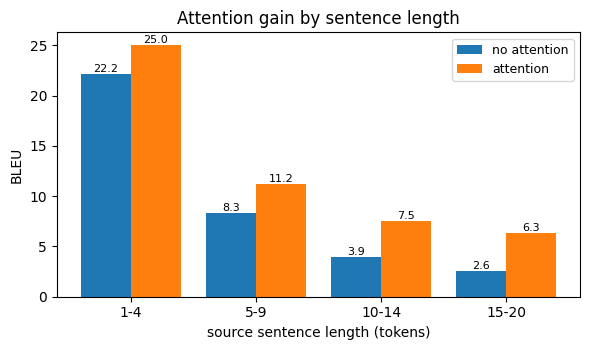

In [14]:
def bleu_by_length(references, hypotheses, pairs, edges=(1, 5, 10, 15, 21)):
    """Smoothed corpus BLEU within source-length buckets."""
    lengths = np.array([len(en.split()) for en, _ in pairs])
    rows = []
    for low, high in zip(edges[:-1], edges[1:]):
        mask = (lengths >= low) & (lengths < high)
        if mask.sum() == 0:
            continue
        refs = [[references[i]] for i in np.where(mask)[0]]
        hyps = [hypotheses[i] for i in np.where(mask)[0]]
        rows.append({"bucket": f"{low}-{high - 1}", "n": int(mask.sum()),
                     "BLEU": 100 * corpus_bleu(refs, hyps,
                                               smoothing_function=SMOOTHING)})
    return pd.DataFrame(rows)

baseline_by_length  = bleu_by_length(baseline_refs,  baseline_hyps,  test_pairs)
attention_by_length = bleu_by_length(attention_refs, attention_hyps, test_pairs)

length_table = baseline_by_length.rename(columns={"BLEU": "BLEU no-attention"})
length_table["BLEU attention"] = attention_by_length["BLEU"]
length_table["gain"] = length_table["BLEU attention"] - length_table["BLEU no-attention"]
length_table = length_table.round(2)
length_table.to_csv(RESULTS_DIR / "bleu_by_source_length.csv", index=False)
print(length_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 3.6))
x = np.arange(len(length_table))
ax.bar(x - 0.2, length_table["BLEU no-attention"], 0.4, label="no attention")
ax.bar(x + 0.2, length_table["BLEU attention"],    0.4, label="attention")
for i, (a, b) in enumerate(zip(length_table["BLEU no-attention"],
                               length_table["BLEU attention"])):
    ax.text(i - 0.2, a, f"{a:.1f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + 0.2, b, f"{b:.1f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(length_table["bucket"])
ax.set_xlabel("source sentence length (tokens)"); ax.set_ylabel("BLEU")
ax.set_title("Attention gain by sentence length"); ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "bleu_by_length.png", dpi=150)
plt.show()

## 8. Visualising the attention weights

The heatmap below shows $\alpha_{t,i}$: how much each **source** word (columns)
contributed to each generated **target** word (rows). A roughly diagonal pattern means
the model learned monotonic word alignment; off-diagonal mass shows where English and
Italian reorder.

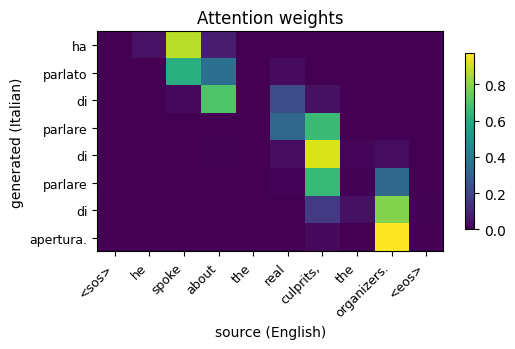

source    : he spoke about the real culprits, the organizers.
reference : ha parlato dei veri colpevoli, gli organizzatori del traffico.
generated : ha parlato di parlare di parlare di apertura.


In [15]:
def plot_attention(pair_index, save_as=None):
    """Translate one test sentence and plot its attention matrix."""
    english, italian = test_pairs[pair_index]
    single = DataLoader(
        TranslationDataset([(english, italian)],
                           english_token_to_index, italian_token_to_index),
        batch_size=1, collate_fn=collate_batch)

    _, hypotheses, weights = generate(attention_model, single, italian_index_to_token,
                                      use_attention=True, keep_weights=True)
    hypothesis = hypotheses[0]
    attention = weights[0][0].numpy()                    # (T, S)

    source_tokens = ["<sos>"] + tokenize(english) + ["<eos>"]
    attention = attention[:len(hypothesis), :len(source_tokens)]

    fig, ax = plt.subplots(figsize=(max(5, 0.55 * len(source_tokens)),
                                    max(3.2, 0.45 * len(hypothesis))))
    im = ax.imshow(attention, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(source_tokens)))
    ax.set_xticklabels(source_tokens, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(hypothesis)))
    ax.set_yticklabels(hypothesis, fontsize=9)
    ax.set_xlabel("source (English)"); ax.set_ylabel("generated (Italian)")
    ax.set_title("Attention weights")
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=150)
    plt.show()

    print(f"source    : {english}")
    print(f"reference : {italian}")
    print(f"generated : {' '.join(hypothesis)}")

# A mid-length sentence shows the alignment structure best.
candidates = [i for i, (en, _) in enumerate(test_pairs) if 6 <= len(en.split()) <= 12]
plot_attention(candidates[0], save_as=RESULTS_DIR / "attention_heatmap.png")

In [16]:
# A couple more examples for qualitative error analysis in the report.
for i in candidates[1:4]:
    english, italian = test_pairs[i]
    single = DataLoader(
        TranslationDataset([(english, italian)],
                           english_token_to_index, italian_token_to_index),
        batch_size=1, collate_fn=collate_batch)
    _, hyp = generate(attention_model, single, italian_index_to_token, use_attention=True)
    _, base_hyp = generate(baseline_model, single, italian_index_to_token,
                           use_attention=False)
    print(f"EN   : {english}")
    print(f"REF  : {italian}")
    print(f"base : {' '.join(base_hyp[0])}")
    print(f"attn : {' '.join(hyp[0])}\n")

EN   : trade relations with certain industrialised countries
REF  : cooperazione e relazioni commerciali ue/paesi industrializzati dell' america settentrionale, dell' estremo oriente e dell' australasia
base : le relazioni esterne hanno perso la loro parte.
attn : i rapporti commerciali con alcuni paesi acp

EN   : the european aviation safety agency must think again.
REF  : l'agenzia europea per la sicurezza aerea deve ripensarci.
base : la politica europea deve inoltre essere in grado di una nuova legislazione.
attn : la sicurezza dei consumatori deve essere la sicurezza interna.

EN   : they continue to report to the competent authorities on a periodic basis.
REF  : quegli istituti dovranno costantemente rendere conto alle autorità competenti su base periodica.
base : invito a continuare a questo punto di vista della direttiva sui prezzi della russia.
attn : essi si devono continuare a sostenere le autorità competenti sulla base del consiglio sulla base di base.



In [17]:
# --- Persist everything the report needs ---
summary = {
    "hyperparameters": {
        "embedding_dimension": EMBEDDING_DIMENSION,
        "hidden_dimension": HIDDEN_DIMENSION,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": NUMBER_OF_EPOCHS,
        "max_sentence_length": MAX_SENTENCE_LENGTH,
        "vocabulary_size": MAX_VOCABULARY_SIZE,
        "attention": "Bahdanau (additive), masked",
        "decoding": "greedy",
        "device": str(DEVICE),
    },
    "baseline": {**baseline_metrics,
                 "validation_loss": baseline_info["validation_loss"],
                 "training_minutes": baseline_info["training_minutes"],
                 "best_epoch": baseline_info["best_epoch"]},
    "attention": {**attention_metrics,
                  "validation_loss": attention_info["validation_loss"],
                  "training_minutes": attention_info["training_minutes"],
                  "best_epoch": attention_info["best_epoch"]},
    "gain": {"BLEU": delta_bleu, "METEOR": delta_meteor},
}
with open(RESULTS_DIR / "task4_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame(baseline_info["history"]).to_csv(
    RESULTS_DIR / "baseline_training_history.csv", index=False)
pd.DataFrame(attention_info["history"]).to_csv(
    RESULTS_DIR / "attention_training_history.csv", index=False)

print(json.dumps(summary, indent=2))
print(f"\nSaved to {RESULTS_DIR}")

{
  "hyperparameters": {
    "embedding_dimension": 64,
    "hidden_dimension": 256,
    "learning_rate": 0.001,
    "batch_size": 128,
    "epochs": 12,
    "max_sentence_length": 20,
    "vocabulary_size": 10000,
    "attention": "Bahdanau (additive), masked",
    "decoding": "greedy",
    "device": "cuda"
  },
  "baseline": {
    "BLEU": 4.160864728271209,
    "METEOR": 18.761279331820194,
    "validation_loss": 3.790189794367912,
    "training_minutes": 2.182238193353017,
    "best_epoch": 12
  },
  "attention": {
    "BLEU": 7.678519393491626,
    "METEOR": 27.07096379431678,
    "validation_loss": 3.3601258231137807,
    "training_minutes": 5.769051460425059,
    "best_epoch": 8
  },
  "gain": {
    "BLEU": 3.517654665220417,
    "METEOR": 8.309684462496584
  }
}

Saved to /content/English-Italian-Machine-Translation-/results/task4_outputs


In [18]:
# --- Get the results OFF Colab before the session dies ---
# Everything in the Colab VM is deleted when the runtime disconnects, so zip the
# outputs and download them. Unzip into results/task4_outputs/ in the local repo,
# then commit. (Checkpoints are excluded: they are large and git-ignored anyway.)
import shutil, sys

archive = shutil.make_archive(
    str(PROJECT_ROOT / "task4_results"), "zip", root_dir=RESULTS_DIR
)
print("archive:", archive)
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name:38} {f.stat().st_size/1024:8.1f} KB")

if "google.colab" in sys.modules:
    from google.colab import files
    files.download(archive)          # browser download prompt
else:
    print("\nNot on Colab - results are already in", RESULTS_DIR)

archive: /content/English-Italian-Machine-Translation-/task4_results.zip
  attention_comparison.csv                    0.1 KB
  attention_heatmap.png                      45.5 KB
  attention_training_history.csv              0.5 KB
  baseline_training_history.csv               0.5 KB
  bleu_by_length.png                         32.3 KB
  bleu_by_source_length.csv                   0.1 KB
  task4_summary.json                          0.8 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. What to write in the report

Fill Section~\ref{sec:attn} of `report/report.tex` with:

1. **The mechanism** — additive attention, masked over padding, and *why* additive
   (no dimension constraint, sharper interpretable weights).
2. **The comparison table** — from `attention_comparison.csv`, best per column in bold.
3. **The length analysis** — from `bleu_by_length.png`. If the gain grows with sentence
   length, that is direct evidence for the bottleneck explanation, and it ties back to
   the length statistics in Task 1.
4. **The heatmap** — `attention_heatmap.png`, with one or two sentences of what the
   alignment shows (monotonic where the languages agree in order, off-diagonal where
   Italian reorders, e.g. adjective–noun inversion).
5. **The cost** — attention trains more slowly because decoding is step-by-step rather
   than one LSTM call. Report both training times; the brief asks about computational
   cost, not only quality.